# LOAD LIBRARIES

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from scipy.stats import linregress
from diive.core.io.files import load_parquet

# CONFIGURATION

In [23]:
START_DATE, END_DATE = '2023-11-08', '2024-07-25' # Wheat
TARGET_FLUX = 'FN2O'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = True
LOG_TRANSFORM = True
ADD_ID = True
UNDERSAMPLE = True

# LOAD DATA

In [24]:
data_main = fluxes = load_parquet(filepath=r"../81.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))

data_main

Loaded .parquet file ../81.1_GapFillingDataset.parquet (0.446 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,prec,ta,timesince_prec,vpd,...,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,1.991226,-0.238835,1.752390,B,certain,0.0,5.333333,12.0,0.180179,...,-1.116706,-1.152150,-0.275176,-0.379151,2.956382,-1.564360,0.573172,-0.047840,-0.181710,-0.177446,0.052573,-1.360142,-0.071378,0.477293,0
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,2.035776,-0.203400,1.832376,B,certain,0.0,5.966667,13.0,0.210078,...,-1.202539,-1.002316,-0.315639,-0.100172,2.819366,-3.022171,0.720981,-0.202111,-0.048345,0.008988,0.015635,-1.939471,0.000852,0.241896,1
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,2.026159,-0.210755,1.815404,B,certain,0.0,5.833333,14.0,0.209377,...,-1.423575,-1.251268,0.154263,0.054827,2.845686,-1.730258,0.304878,0.755972,-0.137978,0.079340,0.129646,-0.687567,0.201061,0.512755,2
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,2.026159,-0.206519,1.819640,B,certain,0.0,5.866667,15.0,0.212335,...,-1.456775,-1.194985,0.190084,0.205121,2.216312,-1.685342,0.385222,0.331593,-0.220338,-0.022307,0.288816,-0.600509,0.215442,0.568651,3
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,2.025592,-0.218648,1.806944,B,certain,0.0,5.766667,16.0,0.210251,...,-1.730865,-1.054997,0.243881,0.243286,1.087768,-1.500100,0.629110,0.868842,-0.175981,-0.027153,0.167790,-0.600174,0.027040,0.576383,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-25 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,6.509221,-1.562339,4.946882,None,None,0.0,16.166667,128.0,0.246013,...,1.979258,0.117887,0.470140,1.934095,0.069588,-0.781542,-0.944345,-0.828950,-0.099631,0.205294,-0.326433,-0.285875,0.167037,-0.173701,12523
2024-07-25 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,6.509221,-1.656828,4.852393,None,None,0.0,15.766667,129.0,0.218872,...,1.702703,0.001131,0.240362,1.779158,-0.057751,-0.904521,-1.299068,-1.184607,-0.106046,0.163649,-0.343612,-0.287530,-0.037435,-0.212412,12524
2024-07-25 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,6.509221,-1.671307,4.837914,None,None,0.0,15.700000,130.0,0.207221,...,1.272358,-0.123926,0.233171,1.737272,-0.048307,-1.044708,-1.119899,-1.157502,-0.137013,0.089801,-0.460830,-0.300689,0.009702,-0.200432,12525


In [25]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs of the target
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')

The target variable is FN2O_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 4.583804143126177

Keeping only data when we are highly confident on the parcel attribution


# SELECT FEATURES

In [26]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 20
# path = 'temp/ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

selected_features = [
'timesince_fert',
'ts_0.3_gfXG_lag9h_roll9hmean',
'n_decay_timed',
'wfps_0.15_gfXG_roll3hmean',
'GPP_U50_f_reddyproc',
'wfps_0.05_gfXG_diff24h',
]

# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data

,timesince_fert,ts_0.3_gfXG_lag9h_roll9hmean,n_decay_timed,wfps_0.15_gfXG_roll3hmean,GPP_U50_f_reddyproc,wfps_0.05_gfXG_diff24h,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,
2023-11-08 00:45:00,22.0,11.216927,29.0,51.748319,-0.203400,-0.202111,0.100302
2023-11-08 01:15:00,22.0,11.189918,29.0,51.804932,-0.210755,0.755972,0.239428
2023-11-08 02:15:00,22.0,11.172378,29.0,51.871311,-0.218648,0.868842,0.358358
2023-11-08 03:15:00,22.0,11.148739,29.0,51.893626,-0.230492,1.042137,0.070120
2023-11-08 04:15:00,22.0,11.119251,29.0,51.873309,-0.152503,1.072204,-0.545573
...,...,...,...,...,...,...,...
2024-07-22 17:15:00,30.0,20.657016,0.0,51.376614,6.524246,5.622711,0.430606
2024-07-22 18:15:00,30.0,20.589465,0.0,51.221110,5.767465,5.626720,0.311525
2024-07-23 05:15:00,30.0,20.198663,0.0,50.658311,0.598910,5.558602,0.314246


# SELECT MODEL

In [27]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 2, 'n_estimators': 300, 'subsample': 0.75}


# IMBALANCE HANDLING

## UNDER SAMPLING

Undersampling target data below: 0.311087692


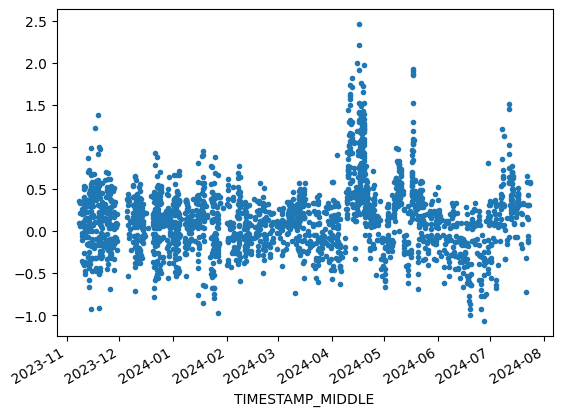

In [28]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.');

## LOG TRANSFORMATION

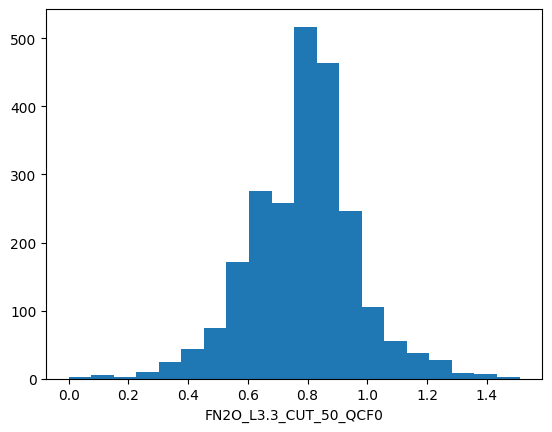

,timesince_fert,ts_0.3_gfXG_lag9h_roll9hmean,n_decay_timed,wfps_0.15_gfXG_roll3hmean,GPP_U50_f_reddyproc,wfps_0.05_gfXG_diff24h,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,
2023-11-08 00:45:00,22.0,11.216927,29.0,51.748319,-0.203400,-0.202111,0.772865
2023-11-08 02:15:00,22.0,11.172378,29.0,51.871311,-0.218648,0.868842,0.885426
2023-11-08 11:45:00,22.0,11.044033,29.0,51.861379,1.610370,0.616091,0.755965
2023-11-08 12:15:00,22.0,11.022433,29.0,51.869228,1.664430,0.714828,0.873966
2023-11-08 12:45:00,23.0,10.994205,29.0,51.872796,2.825652,0.491451,0.825594
...,...,...,...,...,...,...,...
2024-07-22 17:15:00,30.0,20.657016,0.0,51.376614,6.524246,5.622711,0.914796
2024-07-22 18:15:00,30.0,20.589465,0.0,51.221110,5.767465,5.626720,0.865917
2024-07-23 05:15:00,30.0,20.198663,0.0,50.658311,0.598910,5.558602,0.867061


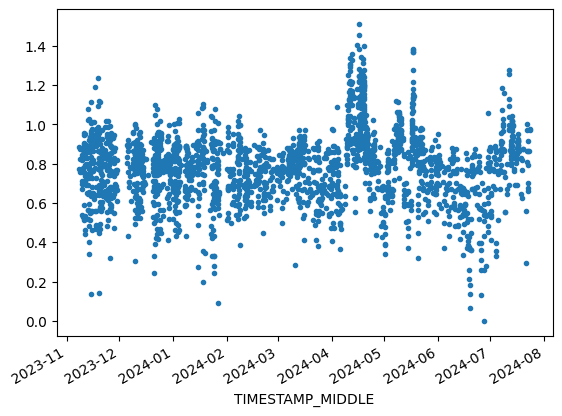

In [29]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])

# Show histogram of TARGET
plt.hist(data[TARGET], bins=20)
plt.xlabel(TARGET)
plt.show()

# Show timeseries
data[TARGET].plot(x_compat=True, style='.');

data

# CROSS-VAL SPLITS

Using stratified approach based on the target variable

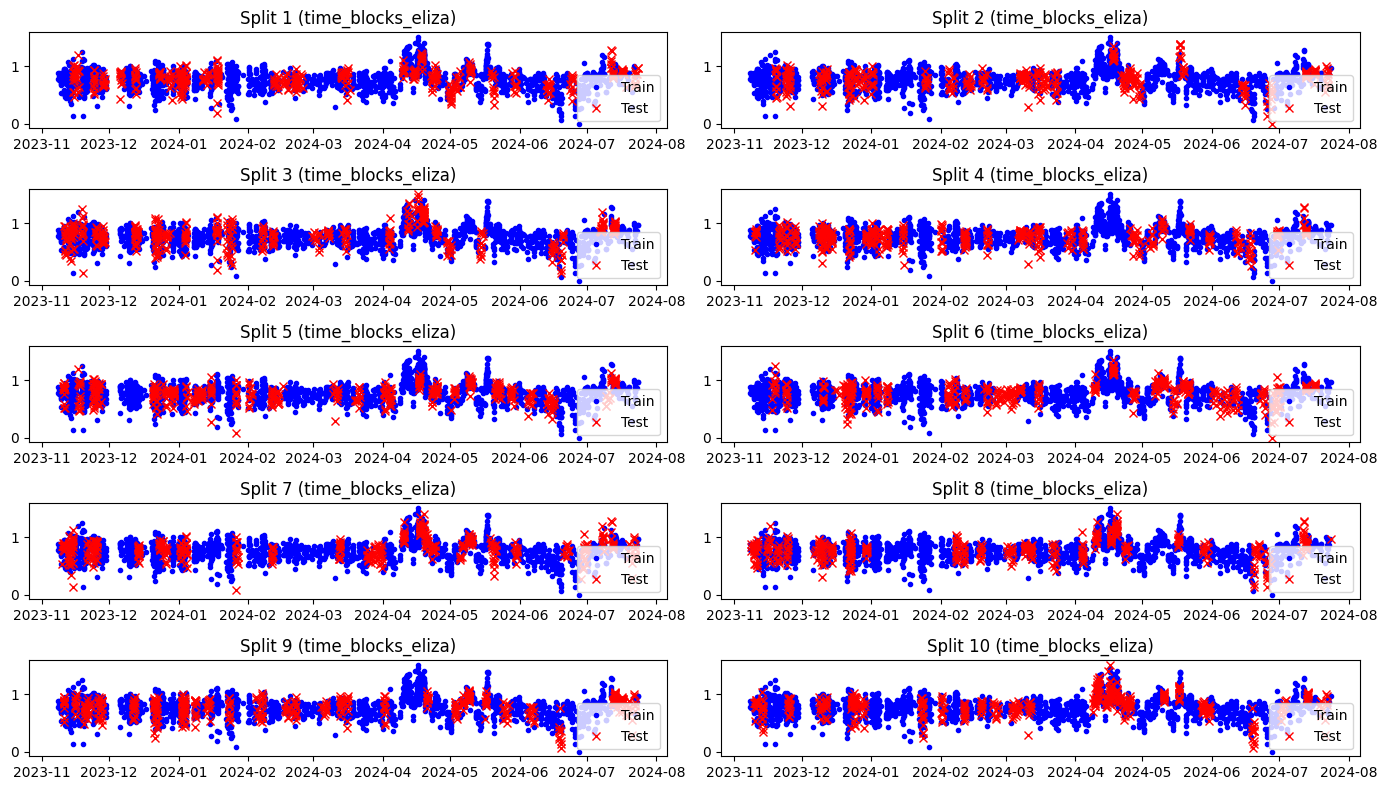

In [30]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    def create_splits(X, y, n_folds, split=0.2, mean_block = 12, min_block=1, random_state=42): # you can set mean block to median_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits


X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# CROSS-VALIDATION

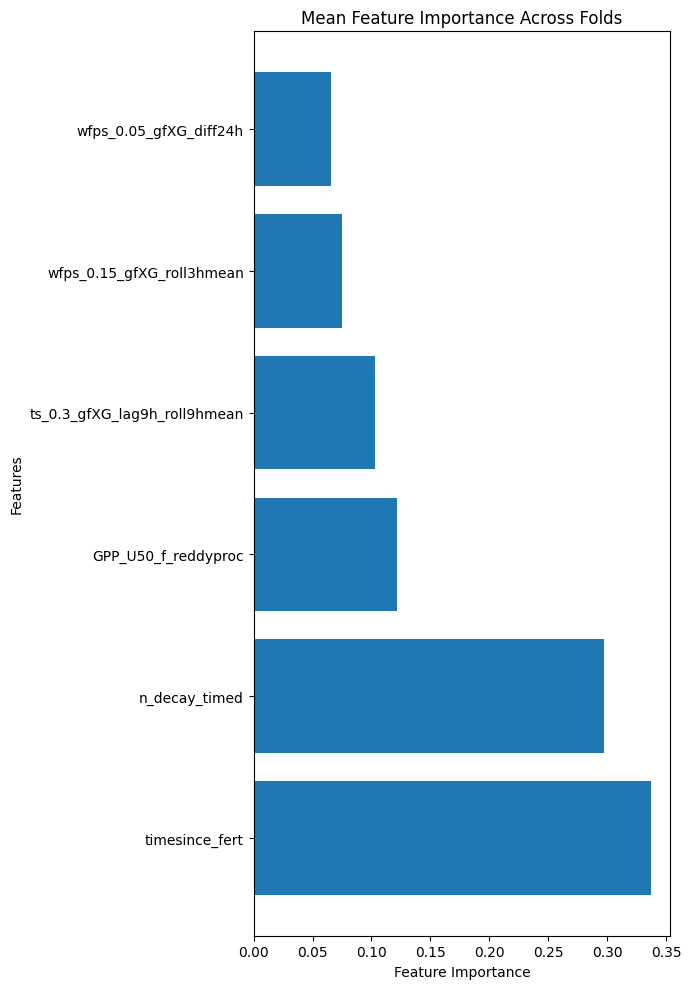

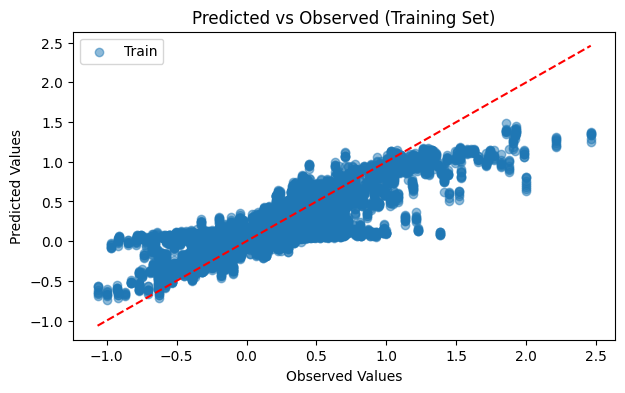

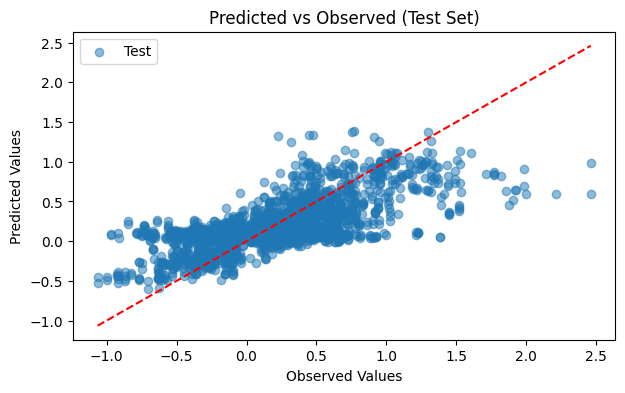

Train RMSE per fold: [0.2603 0.2596 0.2448 0.262  0.2603 0.263  0.2598 0.2591 0.26   0.2581]
Mean Train RMSE: 0.2587
Test RMSE per fold: [0.2749 0.3178 0.3775 0.2618 0.2724 0.2689 0.3085 0.2938 0.272  0.32  ]
Mean Test RMSE: 0.2968
Train R² per fold: [0.6188 0.5933 0.6078 0.6258 0.6285 0.6053 0.6011 0.5951 0.6298 0.5929]
Mean Train R²: 0.6098
Test R² per fold: [0.4023 0.4445 0.4097 0.254  0.2847 0.4752 0.4162 0.5244 0.3222 0.4442]
Mean Test R²: 0.3977


In [31]:
X = data.drop(columns=TARGET)
y = data[TARGET]

# Store results
rmse_train_values, rmse_test_values = [], []
r2_train_values, r2_test_values = [], []
feature_importances_folds = []
y_train_all, y_train_pred_all = [], []
y_test_all, y_pred_test_all = [], []

# Perform cross-validation
for train_idx, test_idx in cross_val_splits:  
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if LOG_TRANSFORM:
        y_train =  inverse_log_transform(y_train)
        y_test =  inverse_log_transform(y_test)
        y_train_pred =  inverse_log_transform(y_train_pred)
        y_test_pred =  inverse_log_transform(y_test_pred)

    # Store RMSE & R² for training and test sets
    rmse_train_values.append(root_mean_squared_error(y_train, y_train_pred))
    rmse_test_values.append(root_mean_squared_error(y_test, y_test_pred))
    r2_train_values.append(r2_score(y_train, y_train_pred))
    r2_test_values.append(r2_score(y_test, y_test_pred))

    # Store feature importances
    feature_importances_folds.append(model.feature_importances_)

    # Store predictions
    y_train_all.extend(y_train)
    y_train_pred_all.extend(y_train_pred)
    y_test_all.extend(y_test)
    y_pred_test_all.extend(y_test_pred)

# Compute mean feature importance across folds
feature_importances = np.nanmean(feature_importances_folds, axis=0)
# Sort feature importances
order = np.argsort(-feature_importances)  # Sort in descending order
feature_names = X_train.columns[order]  # Get feature names sorted by importance

# Plot sorted feature importances
fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names, feature_importances[order])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Mean Feature Importance Across Folds")
fig.tight_layout()
plt.show()

# Plot Predicted vs Observed (Training Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_train_all, y_train_pred_all, alpha=0.5, label="Train")
plt.plot([min(y_train_all), max(y_train_all)], [min(y_train_all), max(y_train_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Training Set)")
plt.legend()
plt.show()

# Plot Predicted vs Observed (Test Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_test_all, y_pred_test_all, alpha=0.5, label="Test")
plt.plot([min(y_test_all), max(y_test_all)], [min(y_test_all), max(y_test_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Test Set)")
plt.legend()
plt.show()

# Print RMSE and R² for both Training and Test sets
print(f"Train RMSE per fold: {np.array(rmse_train_values).round(4)}")
print(f"Mean Train RMSE: {np.mean(rmse_train_values):.4f}")
print(f"Test RMSE per fold: {np.array(rmse_test_values).round(4)}")
print(f"Mean Test RMSE: {np.mean(rmse_test_values):.4f}")

print(f"Train R² per fold: {np.array(r2_train_values).round(4)}")
print(f"Mean Train R²: {np.mean(r2_train_values):.4f}")
print(f"Test R² per fold: {np.array(r2_test_values).round(4)}")
print(f"Mean Test R²: {np.mean(r2_test_values):.4f}")


# FINAL MODEL

## Split train-test

Block splitting with test blocks that can vary of size and we can define the minimum size

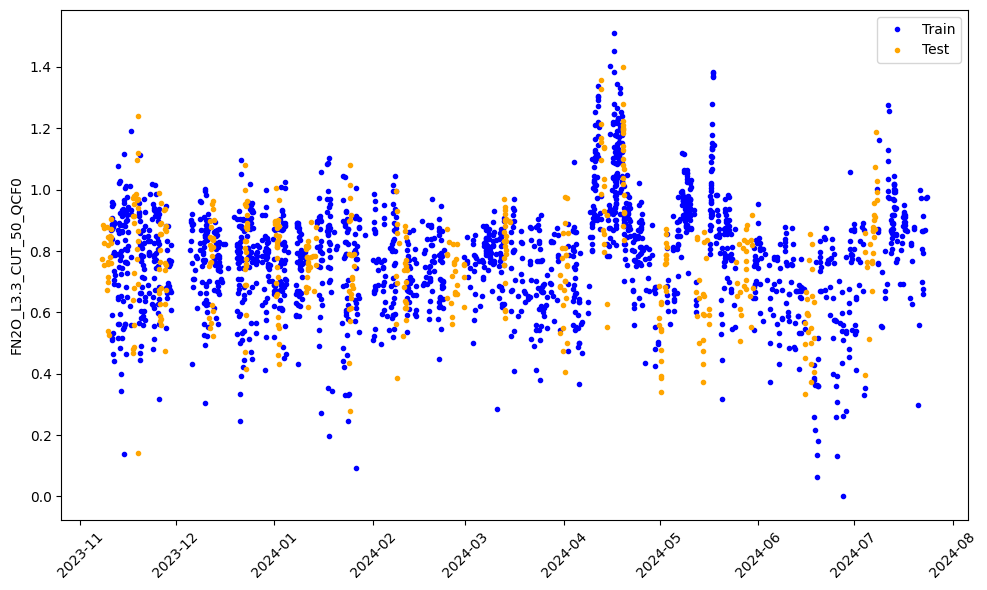

In [32]:
#mean_block = round(mean_nan_size)
mean_block = 24

def split_blocks(X, y, mean_block = mean_block, split=0.2, min_block=3):
       np.random.seed(42)  # Set seed for reproducibility
       tt = np.zeros(len(X)) # space for training/test assignments
       total_test = round(len(X)* split)
       n_blocks = round(total_test/mean_block)
       if mean_block<min_block:
              print("Error: Min block too long for this many blocks")
              return None
       # Vary the length of blocks around the mean (but not below the min)
       blocks = np.array([mean_block + round(v) for v in np.random.normal(0, mean_block/10, n_blocks)])
       blocks[blocks < min_block] = min_block
       # Assign the blocks
       for n, b in enumerate(blocks):
              istart = round(len(X)/(n_blocks))*(n-1)
              iend = istart+b
              tt[istart:iend] = 1
       X_train = X[tt==0]
       X_test = X[tt==1]
       y_train = y[tt==0]
       y_test = y[tt==1]
       # Return sorted data by index (timestamp)
       return X_train.sort_index(), X_test.sort_index(), y_train.sort_index(), y_test.sort_index(), tt

X = data.drop(columns=TARGET)
y = data[TARGET]
X_train, X_test, y_train, y_test, tt = split_blocks(X, y, mean_block=mean_block) # set number of blocks
              
# Check the split
fig, ax = plt.subplots(figsize=(10, 6))  # Adjusted size for better readability
ax.plot(y_train.index, y_train, ".", label="Train", color='blue')
ax.plot(y_test.index, y_test, ".", label="Test", color='orange')
ax.set_ylabel(TARGET)
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()

# Show the plot
plt.show()

## Model training and testing

[0]	validation_0-rmse:0.18230
[1]	validation_0-rmse:0.18178
[2]	validation_0-rmse:0.18127
[3]	validation_0-rmse:0.18084
[4]	validation_0-rmse:0.18021
[5]	validation_0-rmse:0.17995
[6]	validation_0-rmse:0.17935
[7]	validation_0-rmse:0.17896
[8]	validation_0-rmse:0.17839
[9]	validation_0-rmse:0.17806
[10]	validation_0-rmse:0.17773
[11]	validation_0-rmse:0.17742
[12]	validation_0-rmse:0.17710
[13]	validation_0-rmse:0.17663
[14]	validation_0-rmse:0.17608
[15]	validation_0-rmse:0.17583
[16]	validation_0-rmse:0.17538
[17]	validation_0-rmse:0.17495
[18]	validation_0-rmse:0.17459
[19]	validation_0-rmse:0.17422
[20]	validation_0-rmse:0.17401
[21]	validation_0-rmse:0.17357
[22]	validation_0-rmse:0.17337
[23]	validation_0-rmse:0.17314
[24]	validation_0-rmse:0.17288
[25]	validation_0-rmse:0.17247
[26]	validation_0-rmse:0.17221
[27]	validation_0-rmse:0.17176
[28]	validation_0-rmse:0.17158
[29]	validation_0-rmse:0.17124
[30]	validation_0-rmse:0.17110
[31]	validation_0-rmse:0.17096
[32]	validation_0-

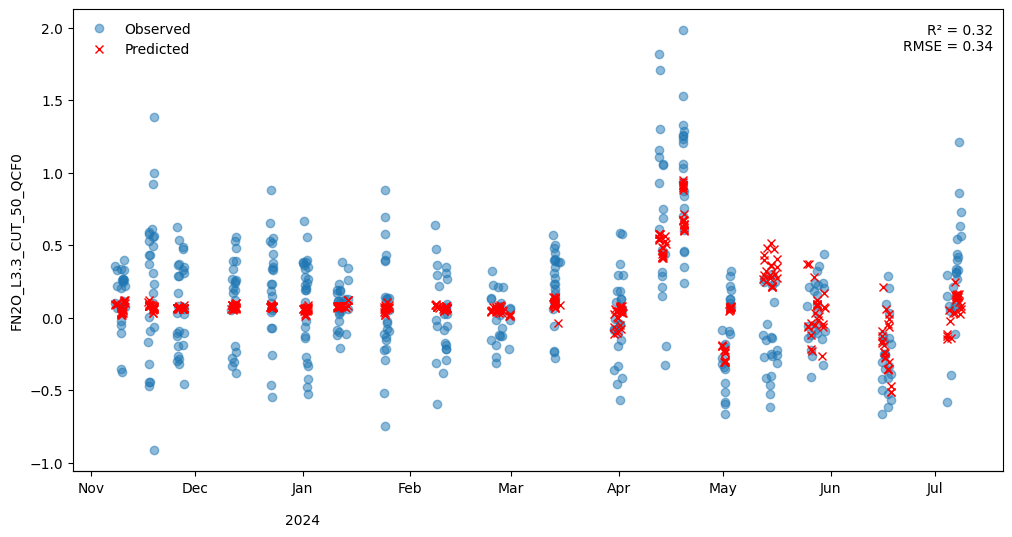

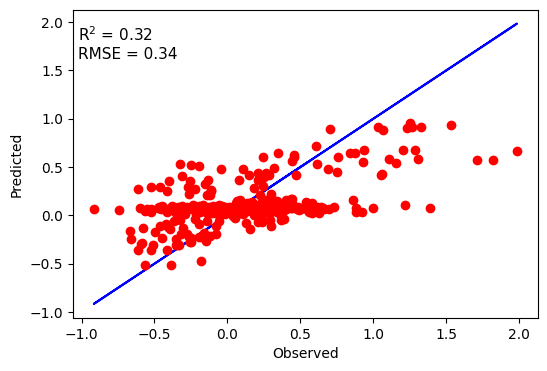

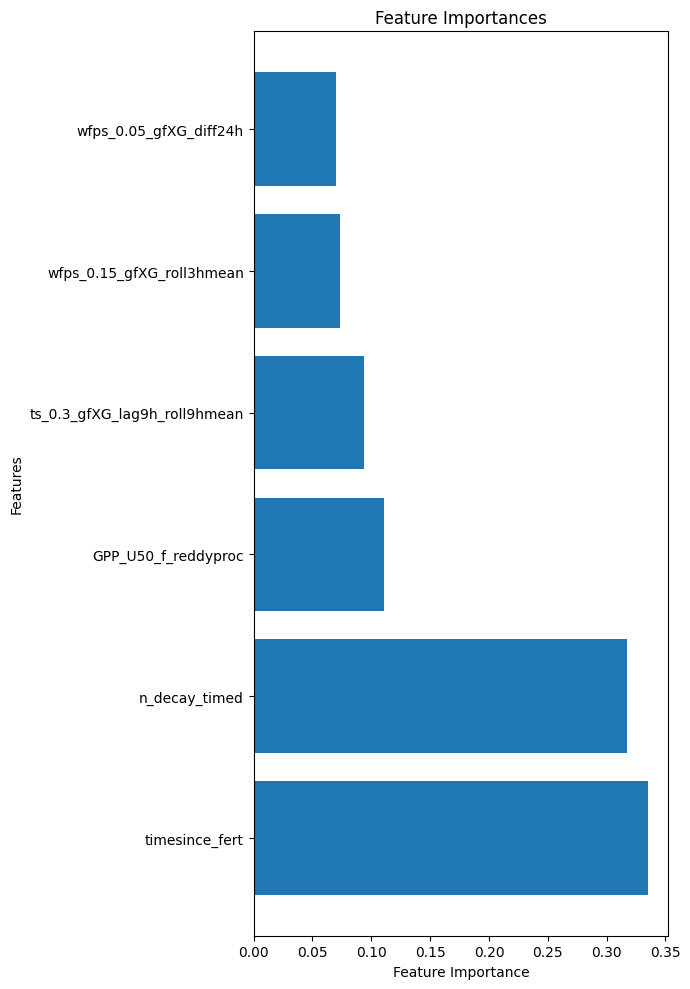

In [33]:
# Use early stopping if using XGBoost
model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse")

# Predict test set
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

# Reverse the log transformation on the predictions and the original transformed data when the transformation was used
if LOG_TRANSFORM:
    pred_train = inverse_log_transform(pred_train) 
    pred_test = inverse_log_transform(pred_test)
    y_train = inverse_log_transform(y_train)
    y_test = inverse_log_transform(y_test)

# Calculate R-squared and Mean Squared Error (MSE) for the training set
r2_train = r2_score(y_train, pred_train)
print(f"R-squared (Training set): {r2_train:.4f}")
rmse_train = root_mean_squared_error(y_train, pred_train)
print(f"Root Mean Squared Error (Training set): {rmse_train:.4f}")
# Calculate R-squared and Mean Squared Error (MSE) for the test set
r2_test = r2_score(y_test, pred_test)
print(f"R-squared (Test set): {r2_test:.4f}")
rmse_test = root_mean_squared_error(y_test, pred_test)
print(f"Root Mean Squared Error (Test set): {rmse_test:.4f}")

# Time series plot
fig, ax = plt.subplots(1,figsize=(12, 6))
ax.plot(y_test.index, y_test,"o",label=("Observed"), alpha=0.5)
ax.plot(y_test.index, pred_test,"rx",label=("Predicted"))
# Format x-axis for months
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Major ticks for months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as month abbreviation
# Add secondary x-axis for years
secax = ax.secondary_xaxis('bottom')
secax.xaxis.set_major_locator(mdates.YearLocator())  # Year ticks
secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as year
secax.tick_params(axis='x', length=0, pad=30)  # Add padding for better readability
# Add R2 and RMSE text
ax.text(0.99, 0.97, f'R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', ha='right')
ax.set_ylabel(TARGET)
ax.legend(frameon=False, loc="upper left")
# save fig
plt.savefig(f'{TARGET}_gapfilling_testset_performance.png', dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Obs Vs predicted
fig, ax = plt.subplots(1,figsize=(6,4))
ax.plot(y_test,y_test,"b-")
ax.plot(y_test,pred_test,"ro")
# Add R2 and RMSE text
ax.text(0.01, 0.95, f'R$^{2}$ = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', fontsize=11)
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
plt.show()

# Plot feature importances
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # Sort descending
feature_names_sorted = X_train.columns[sorted_idx]

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names_sorted, importances[sorted_idx])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Feature Importances")
plt.tight_layout()
plt.show()

# SHAP ANALYSIS

## RUN SHAP

In [34]:
# define background dataset
background_dataset = data_main[selected_features]

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(model, data=background_dataset)

# Calculate SHAP values for the entire dataset
X = data_main[selected_features]
shap_values = explainer(X, check_additivity=True)

# Print the expected value
print("Baseline (expected value):", explainer.expected_value)
if LOG_TRANSFORM:
    print("Baseline without transformation (expected value):", inverse_log_transform(explainer.expected_value))

 99%|===================| 12450/12528 [01:24<00:00]        

Baseline (expected value): 0.7626242677728376
Baseline without transformation (expected value): 0.07823509923707084


## SUMMARY PLOT

C:\Users\turcof\AppData\Local\Temp\ipykernel_7724\3044024046.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X, show=False)


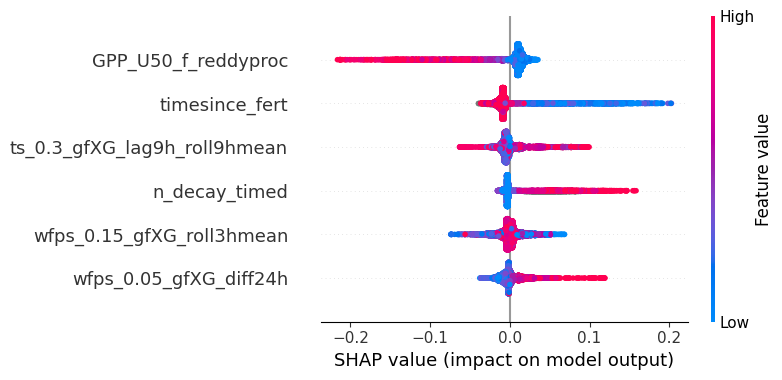

In [35]:
# SHAP summary plot
fig = plt.figure()
shap.summary_plot(shap_values, X, show=False)
# Save the figure
fig.savefig(f'{TARGET}_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## SHAP SCATTERPLOTS

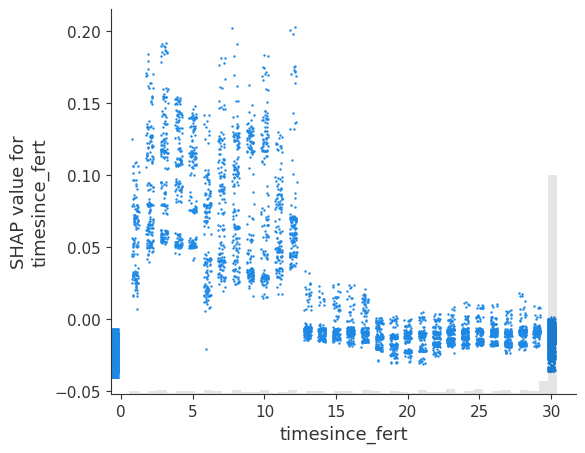

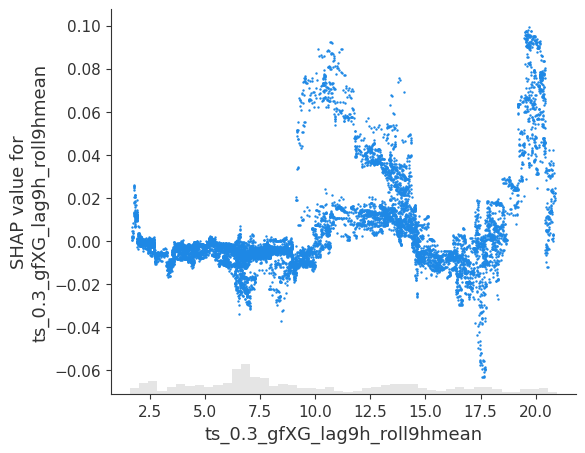

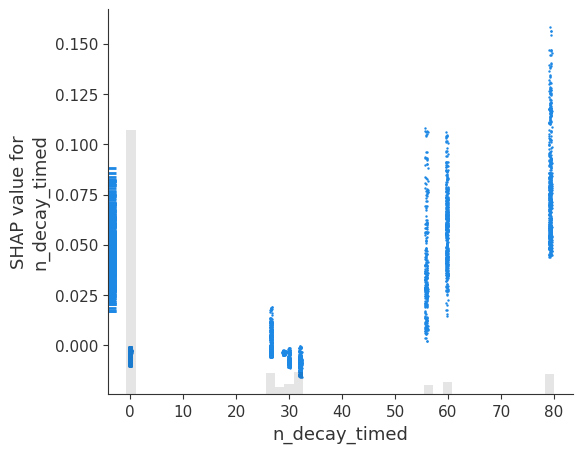

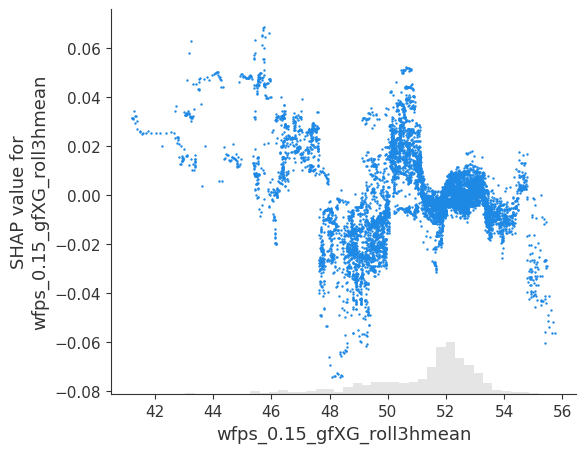

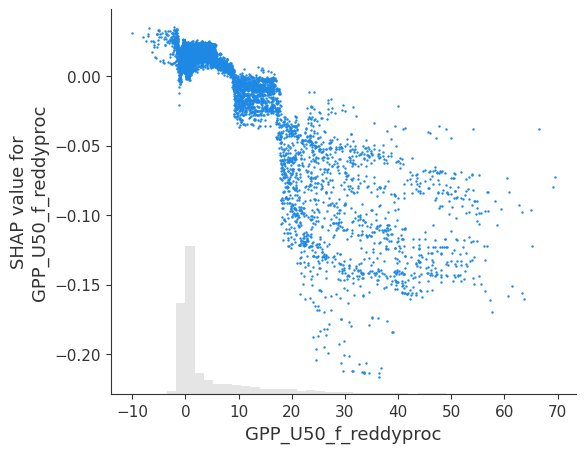

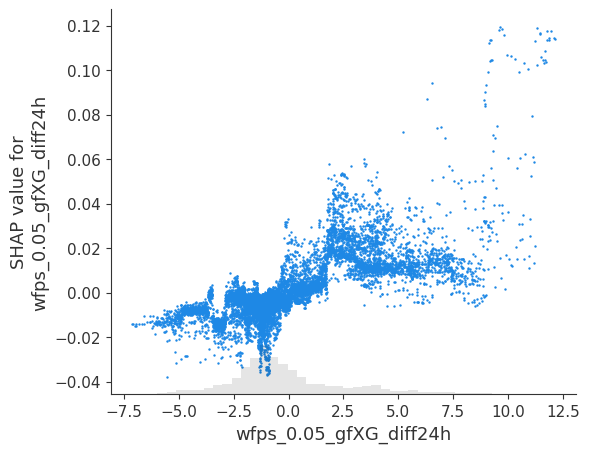

In [36]:
# Dependence plots

for var in X.columns:
    shap.plots.scatter(shap_values[:, var], dot_size=3, x_jitter=0.5)
#    shap.dependence_plot(var, shap_values.values, X)
    plt.show()

# GAP-FILLING

In [39]:
selected_features

['timesince_fert',
 'ts_0.3_gfXG_lag9h_roll9hmean',
 'n_decay_timed',
 'wfps_0.15_gfXG_roll3hmean',
 'GPP_U50_f_reddyproc',
 'wfps_0.05_gfXG_diff24h']

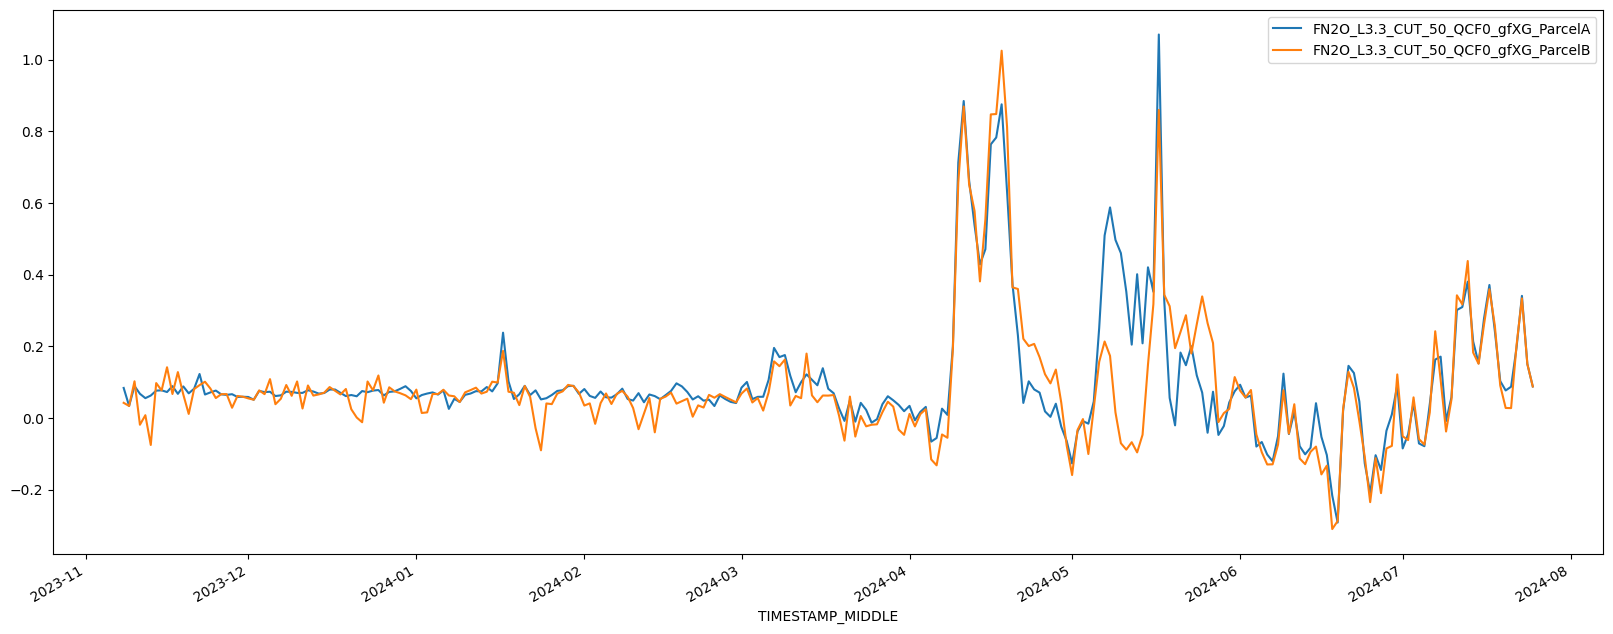

In [ ]:
selected_features_A = [
'timesince_fert_parcelA',
 'ts_0.3_gfXG_lag9h_roll9hmean',
 'n_decay_timed_parcelA',
 'wfps_0.15_gfXG_roll3hmean',
 'GPP_U50_f_reddyproc',
 'wfps_0.05_gfXG_diff24h']
X_A = data_main[selected_features_A].rename(columns={'timesince_fert_parcelA': 'timesince_fert', 'n_decay_timed_parcelA': 'n_decay_timed'})
predicted_A = model.predict(X_A)
if LOG_TRANSFORM:
    predicted_A = inverse_log_transform(predicted_A)
# Mask for parcel A
mask_A = (data_main['parcel'] == 'A') & (data_main['parcel_certainty'] == 'certain')
# start with predictions everywhere
data_main[f'{TARGET}_gfXG_ParcelA'] = predicted_A  
# overwrite with original values where the condition is met
data_main.loc[mask_A, f'{TARGET}_gfXG_ParcelA'] = data_main.loc[mask_A, TARGET]

selected_features_B = [
'timesince_fert_parcelB',
 'ts_0.3_gfXG_lag9h_roll9hmean',
 'n_decay_timed_parcelB',
 'wfps_0.15_gfXG_roll3hmean',
 'GPP_U50_f_reddyproc',
 'wfps_0.05_gfXG_diff24h']
X_B = data_main[selected_features_B].rename(columns={'timesince_fert_parcelB': 'timesince_fert', 'n_decay_timed_parcelB': 'n_decay_timed'})
predicted_B = model.predict(X_B)
if LOG_TRANSFORM:
    predicted_B = inverse_log_transform(predicted_B)
# Mask for parcel B
mask_B = (data_main['parcel'] == 'B') & (data_main['parcel_certainty'] == 'certain')
# start with predictions everywhere
data_main[f'{TARGET}_gfXG_ParcelB'] = predicted_B  
# overwrite with original values where the condition is met
data_main.loc[mask_B, f'{TARGET}_gfXG_ParcelB'] = data_main.loc[mask_B, TARGET]


data_main[[f'{TARGET}_gfXG_ParcelA', f'{TARGET}_gfXG_ParcelB']].resample('D').mean().plot(figsize=(20,8), x_compat=True);

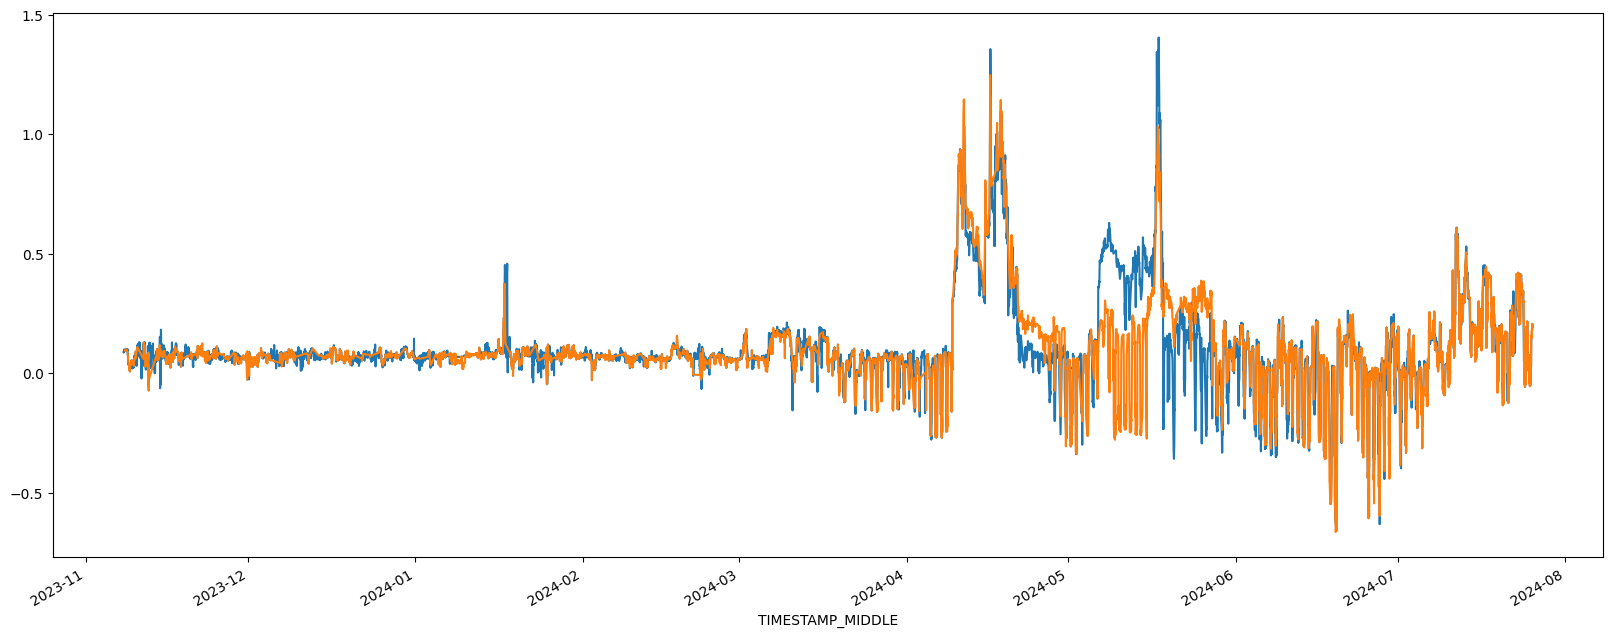

In [49]:
data_main.loc[~mask_A, f'{TARGET}_gfXG_ParcelA'].plot(figsize=(20,8), x_compat=True);
data_main.loc[~mask_B, f'{TARGET}_gfXG_ParcelB'].plot(figsize=(20,8), x_compat=True);